In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Wine dataset

wine = load_wine()

print("Wine dataset loaded successfully!")

Wine dataset loaded successfully!


In [3]:
# Creating a Pandas DataFrame

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Displaying the first five rows

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [5]:
# Statistical summary of the dataset

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
# Checking for missing values

df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [7]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 178
Columns : 13


In [8]:
# Displaying all feature names

print("Features in the Wine dataset:")

for i, feature in enumerate(wine.feature_names, start=1):
    print(i, ":", feature)

Features in the Wine dataset:
1 : alcohol
2 : malic_acid
3 : ash
4 : alcalinity_of_ash
5 : magnesium
6 : total_phenols
7 : flavanoids
8 : nonflavanoid_phenols
9 : proanthocyanins
10 : color_intensity
11 : hue
12 : od280/od315_of_diluted_wines
13 : proline


In [9]:
# Separating features and target

X = df.copy()
y = wine.target

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (178, 13)
Target Shape  : (178,)


In [10]:
# Displaying features and target

print("Features:")
display(X.head())

print("\nTarget:")
print(y[:10])

Features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Target:
[0 0 0 0 0 0 0 0 0 0]


In [11]:
# Standardizing the features before applying PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
display(pd.DataFrame(
    X_scaled,
    columns=X.columns
).head())

Scaled Features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [12]:
# Checking mean and standard deviation after scaling

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Mean of scaled features:")
print(scaled_df.mean())

print("\nStandard deviation of scaled features:")
print(scaled_df.std())

Mean of scaled features:
alcohol                        -8.382808e-16
malic_acid                     -1.197544e-16
ash                            -8.370333e-16
alcalinity_of_ash              -3.991813e-17
magnesium                      -3.991813e-17
total_phenols                   0.000000e+00
flavanoids                     -3.991813e-16
nonflavanoid_phenols            3.592632e-16
proanthocyanins                -1.197544e-16
color_intensity                 2.494883e-17
hue                             1.995907e-16
od280/od315_of_diluted_wines    3.193450e-16
proline                        -1.596725e-16
dtype: float64

Standard deviation of scaled features:
alcohol                         1.002821
malic_acid                      1.002821
ash                             1.002821
alcalinity_of_ash               1.002821
magnesium                       1.002821
total_phenols                   1.002821
flavanoids                      1.002821
nonflavanoid_phenols            1.002821
proanth

In [13]:
# Creating the PCA model

pca = PCA()

print("PCA model created successfully!")

PCA model created successfully!


In [14]:
# Fitting PCA on the scaled features

pca.fit(X_scaled)

print("PCA model fitted successfully!")

PCA model fitted successfully!


In [15]:
# Displaying the variance explained by each principal component

explained_variance = pca.explained_variance_

print("Explained Variance:")
print(explained_variance)

Explained Variance:
[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868 0.64528221
 0.55414147 0.35046627 0.29051203 0.25232001 0.22706428 0.16972374
 0.10396199]


In [16]:
# Calculating the explained variance ratio

explained_variance_ratio = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance_ratio)

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [17]:
# Creating a DataFrame for explained variance

variance_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(explained_variance_ratio))
    ],
    "Explained Variance Ratio": explained_variance_ratio
})

display(variance_df)

,Principal Component,Explained Variance Ratio
0,PC1,0.361988
1,PC2,0.192075
2,PC3,0.111236
3,PC4,0.070690
4,PC5,0.065633
5,PC6,0.049358
6,PC7,0.042387
7,PC8,0.026807
8,PC9,0.022222
9,PC10,0.019300


In [18]:
# Calculating cumulative explained variance

cumulative_variance = np.cumsum(
    explained_variance_ratio
)

print("Cumulative Explained Variance:")
print(cumulative_variance)

Cumulative Explained Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


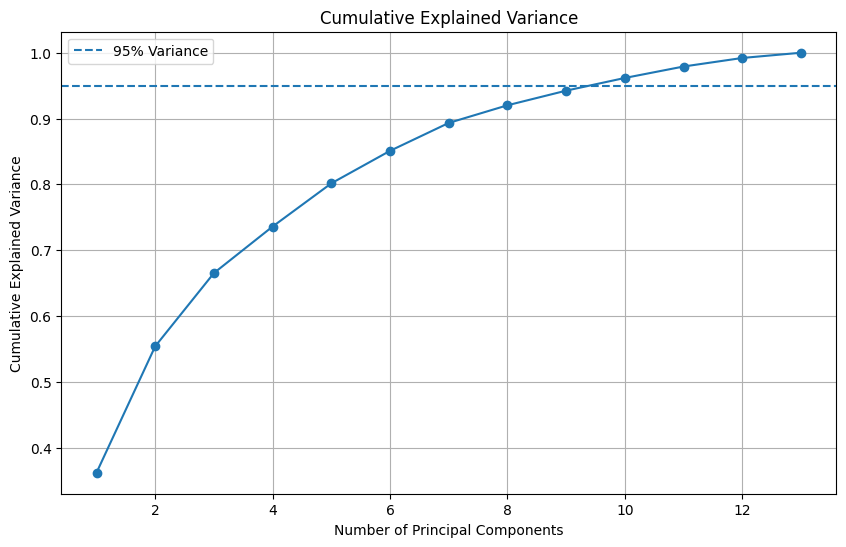

In [19]:
# Plotting cumulative explained variance

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.grid()
plt.legend()
plt.show()


In [20]:
# Selecting the number of principal components

n_components = 2

print("Selected Number of Components:", n_components)

Selected Number of Components: 2


In [21]:
# Creating PCA with 2 principal components

pca_2 = PCA(
    n_components=n_components
)

print("PCA with 2 components created successfully!")

PCA with 2 components created successfully!


In [22]:
# Transforming the original 13 features into 2 principal components

X_pca = pca_2.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("PCA Shape      :", X_pca.shape)

Original Shape : (178, 13)
PCA Shape      : (178, 2)


In [23]:
# Displaying the transformed PCA data

print("First 10 PCA observations:")

display(pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
).head(10))

First 10 PCA observations:


,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831
5,3.050254,2.122401
6,2.449090,1.174850
7,2.059437,1.608963
8,2.510874,0.918071
9,2.753628,0.789438


In [24]:
# Creating a DataFrame containing the principal components

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

display(pca_df.head())

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


In [25]:
# Adding the original wine class to the PCA DataFrame

pca_df["Target"] = y

display(pca_df.head(10))

,PC1,PC2,Target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0
5,3.050254,2.122401,0
6,2.449090,1.174850,0
7,2.059437,1.608963,0
8,2.510874,0.918071,0
9,2.753628,0.789438,0


In [26]:
# Checking how much variance is retained by the two selected components

pca_variance = pca_2.explained_variance_ratio_

print("PC1 Variance :", pca_variance[0])
print("PC2 Variance :", pca_variance[1])

print("\nTotal Variance Retained :",
      pca_variance.sum())

PC1 Variance : 0.3619884809992633
PC2 Variance : 0.19207490257008944

Total Variance Retained : 0.5540633835693527


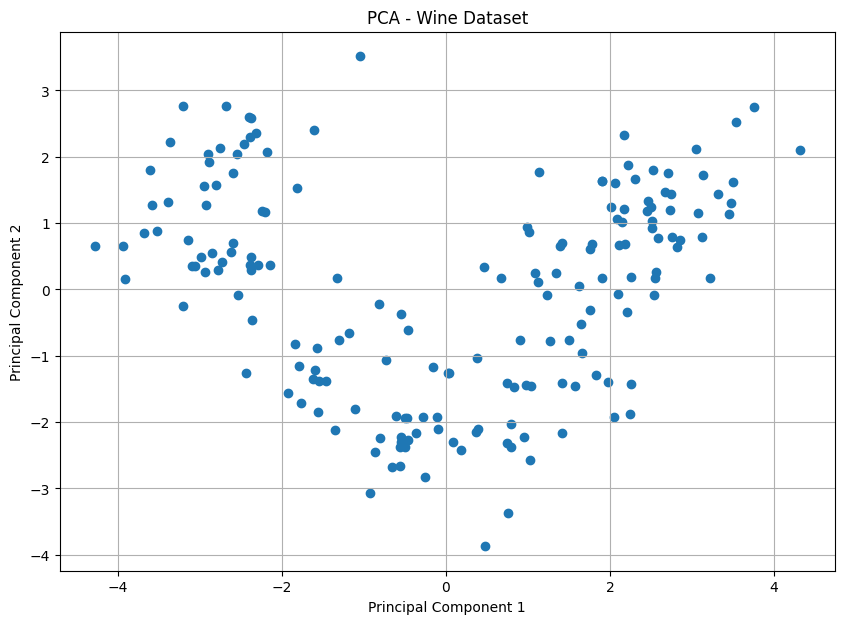

In [27]:
# Visualizing the Wine dataset using the first two principal components

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

plt.title("PCA - Wine Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid()
plt.show()

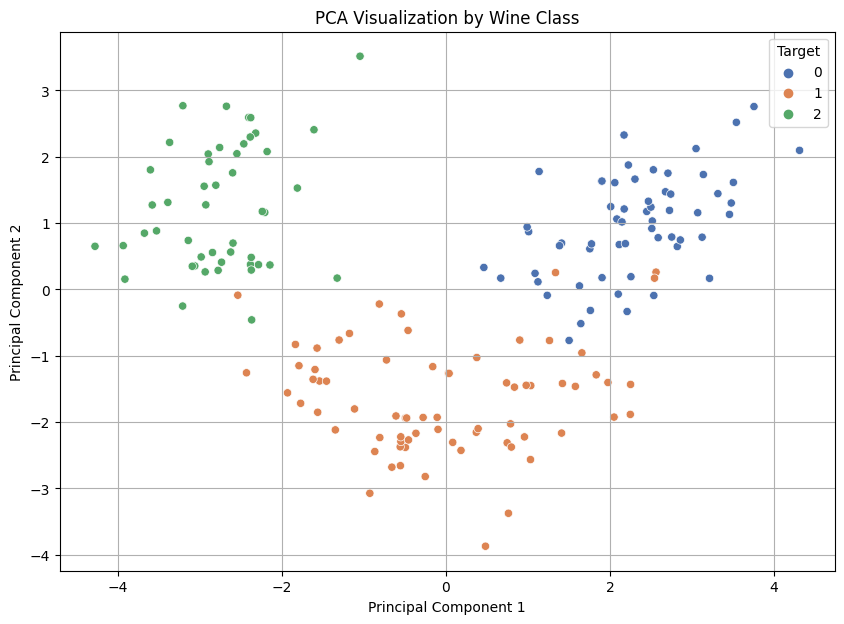

In [28]:
# Visualizing PCA components according to the original wine classes

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep"
)

plt.title("PCA Visualization by Wine Class")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid()
plt.show()

In [29]:
# Displaying the contribution of original features to the principal components

components_df = pd.DataFrame(
    pca_2.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

display(components_df)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
PC1,0.144329,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752
PC2,0.483652,0.224931,0.316069,-0.010591,0.299634,0.065040,-0.003360,0.028779,0.039302,0.529996,-0.279235,-0.164496,0.364903


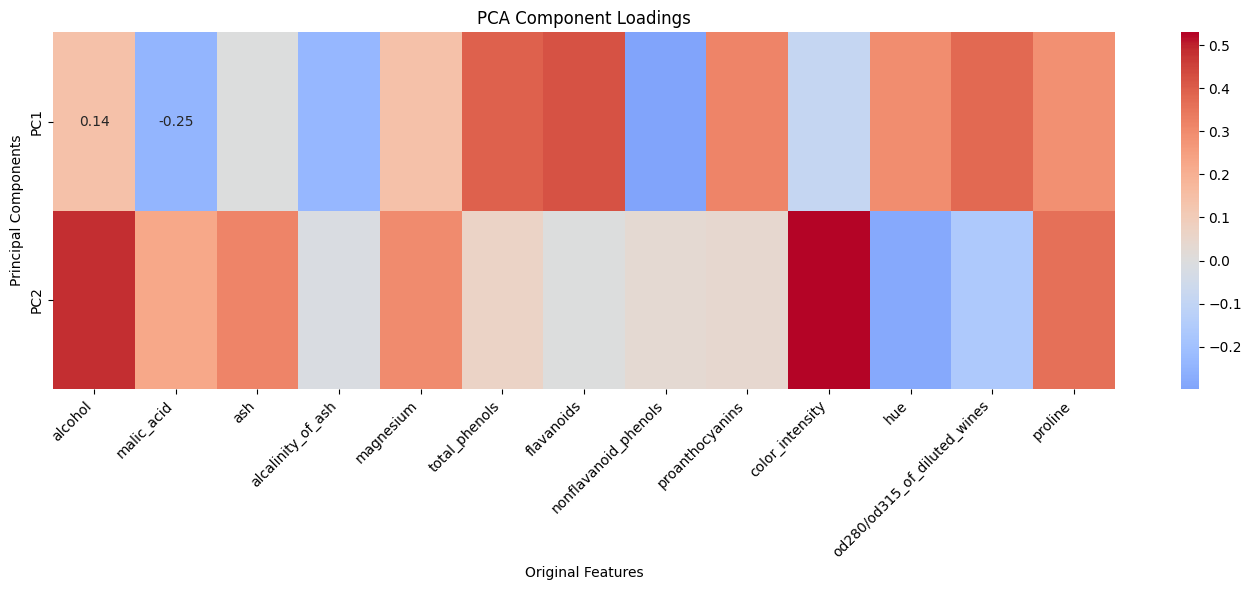

In [30]:
# Visualizing feature contributions to PC1 and PC2

plt.figure(figsize=(14, 6))

sns.heatmap(
    components_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Component Loadings")
plt.xlabel("Original Features")
plt.ylabel("Principal Components")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()